In [ ]:
import xarray as xr
import rasterio
from rasterio.plot import show
import warnings
warnings.filterwarnings('ignore')

# Environmental Variables Analysis from NetCDF Files

In [ ]:
# Load and Analyze NetCDF Environmental Variables

import xarray as xr
import glob
from pathlib import Path

# Define paths to environmental data
env_data_path = '../../dataset/env_copernius'

# List all available NetCDF files
nc_files = sorted(glob.glob(f'{env_data_path}/**/*.nc', recursive=True))

print(f"Found {len(nc_files)} NetCDF files")
print("\nAvailable environmental variables:")
for i, file in enumerate(nc_files[:10]):
    print(f"{i+1}. {Path(file).name}")

# Load a sample NetCDF file to understand structure
sample_file = nc_files[0]
print(f"\n\nAnalyzing sample file: {Path(sample_file).name}")

# Open with xarray
ds = xr.open_dataset(sample_file)
print("\nDataset structure:")
print(ds)

# Get variable information
print("\nVariables in dataset:")
for var in ds.data_vars:
    print(f"  - {var}: {ds[var].shape}, dtype: {ds[var].dtype}")

print("\nCoordinates:")
for coord in ds.coords:
    print(f"  - {coord}: {ds[coord].shape}")

In [ ]:
# Load Multiple Environmental Variables and Create Raster Stack

import xarray as xr
import glob
from pathlib import Path

# Define environmental variable files to load
env_files = {
    'thetao': '../../dataset/env_copernius/env_2025/phy_thetao_2025.nc',
    'so': '../../dataset/env_copernius/env_2025/phy_so_2025.nc',
    'mlotst': '../../dataset/env_copernius/env_2025/phy_mlotst_2025.nc',
    'o2': '../../dataset/env_copernius/env_2025/bio_o2_2025.nc',
    'chl_phyc': '../../dataset/env_copernius/env_2025/bio_chl_phyc_2025.nc'
}

# Load all environmental variables
env_data = {}
print("Loading environmental variables:")
for var_name, file_path in env_files.items():
    try:
        ds = xr.open_dataset(file_path)
        # Get the main data variable (usually the first one)
        data_var = list(ds.data_vars)[0]
        env_data[var_name] = ds[data_var]
        print(f"✓ {var_name}: shape {ds[data_var].shape}")
    except FileNotFoundError:
        print(f"✗ {var_name}: File not found")
    except Exception as e:
        print(f"✗ {var_name}: Error - {str(e)}")

# Display summary of loaded data
print(f"\nTotal variables loaded: {len(env_data)}")
if env_data:
    first_var = list(env_data.values())[0]
    print(f"Spatial extent: Lat {first_var.lat.min().values:.2f} to {first_var.lat.max().values:.2f}")
    print(f"                Lon {first_var.lon.min().values:.2f} to {first_var.lon.max().values:.2f}")
    print(f"Temporal coverage: {first_var.time.values if 'time' in first_var.dims else 'Single timestep'}")

In [ ]:
# Visualize Environmental Variables as Raster Data

import xarray as xr
import matplotlib.pyplot as plt

# Load a single environmental variable for visualization
thetao_file = '../../dataset/env_copernius/env_2025/phy_thetao_2025.nc'
ds_thetao = xr.open_dataset(thetao_file)

# Get the main variable
var_name = list(ds_thetao.data_vars)[0]
thetao_data = ds_thetao[var_name]

print(f"Variable: {var_name}")
print(f"Shape: {thetao_data.shape}")
print(f"Data range: {float(thetao_data.min().values):.2f} to {float(thetao_data.max().values):.2f}")

# Create visualization of raster data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Full raster
if 'time' in thetao_data.dims:
    data_to_plot = thetao_data.isel(time=0)
else:
    data_to_plot = thetao_data

im1 = axes[0].imshow(data_to_plot.values, cmap='viridis', aspect='auto')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title(f'{var_name} - Full Raster')
plt.colorbar(im1, ax=axes[0], label=f'{var_name} Value')

# Plot 2: Zoomed to study area (Southeast Asia)
lat_min, lat_max = -10, 40
lon_min, lon_max = 25, 145

lat_idx = (data_to_plot.lat >= lat_min) & (data_to_plot.lat <= lat_max)
lon_idx = (data_to_plot.lon >= lon_min) & (data_to_plot.lon <= lon_max)

data_zoomed = data_to_plot.where(lat_idx & lon_idx, drop=True)

im2 = axes[1].imshow(data_zoomed.values, cmap='viridis', aspect='auto', 
                     extent=[lon_min, lon_max, lat_min, lat_max])
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title(f'{var_name} - Study Area (Southeast Asia)')
plt.colorbar(im2, ax=axes[1], label=f'{var_name} Value')

plt.tight_layout()
plt.show()

print(f"\nStudy area extent:")
print(f"  Latitude: {lat_min} to {lat_max}")
print(f"  Longitude: {lon_min} to {lon_max}")

In [ ]:
# Predictor Variables Visualization and Statistics

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Load multiple environmental variables
env_files = {
    'Temperature (°C)': '../../dataset/env_copernius/env_2025/phy_thetao_2025.nc',
    'Salinity (PSU)': '../../dataset/env_copernius/env_2025/phy_so_2025.nc',
    'Mixed Layer Depth (m)': '../../dataset/env_copernius/env_2025/phy_mlotst_2025.nc',
    'Oxygen (mmol/m³)': '../../dataset/env_copernius/env_2025/bio_o2_2025.nc'
}

# Extract study area bounds
lat_min, lat_max = -10, 40
lon_min, lon_max = 25, 145

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

stats_summary = {}

for idx, (label, file_path) in enumerate(env_files.items()):
    try:
        ds = xr.open_dataset(file_path)
        var_name = list(ds.data_vars)[0]
        data = ds[var_name]
        
        # Extract study area
        if 'time' in data.dims:
            data = data.isel(time=0)
        
        lat_idx = (data.lat >= lat_min) & (data.lat <= lat_max)
        lon_idx = (data.lon >= lon_min) & (data.lon <= lon_max)
        data_study = data.where(lat_idx & lon_idx, drop=True)
        
        # Calculate statistics
        valid_data = data_study.values[~np.isnan(data_study.values)]
        stats_summary[label] = {
            'mean': np.mean(valid_data),
            'std': np.std(valid_data),
            'min': np.min(valid_data),
            'max': np.max(valid_data),
            'count': len(valid_data)
        }
        
        # Plot raster
        im = axes[idx].imshow(data_study.values, cmap='RdYlBu_r', aspect='auto')
        axes[idx].set_xlabel('Longitude')
        axes[idx].set_ylabel('Latitude')
        axes[idx].set_title(label)
        plt.colorbar(im, ax=axes[idx])
        
    except Exception as e:
        axes[idx].text(0.5, 0.5, f'Error loading {label}\n{str(e)}', 
                      ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(label)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*70)
print("PREDICTOR VARIABLES STATISTICS (Study Area)")
print("="*70)
for label, stats in stats_summary.items():
    print(f"\n{label}:")
    print(f"  Mean:  {stats['mean']:.4f}")
    print(f"  Std:   {stats['std']:.4f}")
    print(f"  Min:   {stats['min']:.4f}")
    print(f"  Max:   {stats['max']:.4f}")
    print(f"  Valid pixels: {stats['count']:,}")

In [ ]:
# Fish Point Distribution Visualization

import matplotlib.pyplot as plt
import numpy as np

# Load fish occurrence data
fish_data = pd.read_csv('../../dataset/fish_env_2022_2025.csv')

# Define study area
lat_min, lat_max = -10, 40
lon_min, lon_max = 25, 145

# Filter data to study area
fish_study = fish_data[
    (fish_data['decimalLatitude'] >= lat_min) & 
    (fish_data['decimalLatitude'] <= lat_max) &
    (fish_data['decimalLongitude'] >= lon_min) & 
    (fish_data['decimalLongitude'] <= lon_max)
].copy()

print(f"Total fish records: {len(fish_data)}")
print(f"Records in study area: {len(fish_study)}")
print(f"Study area coverage: {len(fish_study)/len(fish_data)*100:.1f}%")

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Plot 1: All fish points
ax1 = fig.add_subplot(gs[0, 0])
scatter1 = ax1.scatter(fish_study['decimalLongitude'], fish_study['decimalLatitude'], 
                       c='blue', s=30, alpha=0.6, edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_title(f'Fish Species Distribution ({len(fish_study)} records)')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(lon_min, lon_max)
ax1.set_ylim(lat_min, lat_max)

# Plot 2: Points by species
ax2 = fig.add_subplot(gs[0, 1])
species_counts = fish_study['scientificName'].value_counts().head(10)
colors_species = plt.cm.tab10(np.linspace(0, 1, len(species_counts)))

for idx, (species, count) in enumerate(species_counts.items()):
    species_data = fish_study[fish_study['scientificName'] == species]
    ax2.scatter(species_data['decimalLongitude'], species_data['decimalLatitude'],
               label=f'{species.split()[-1]} (n={count})', s=40, alpha=0.6, 
               color=colors_species[idx], edgecolors='black', linewidth=0.5)

ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_title('Fish Distribution by Top 10 Species')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(lon_min, lon_max)
ax2.set_ylim(lat_min, lat_max)

# Plot 3: Temporal distribution
ax3 = fig.add_subplot(gs[1, 0])
fish_study['year'] = pd.to_numeric(fish_study['year'], errors='coerce')
yearly_counts = fish_study['year'].value_counts().sort_index()
ax3.bar(yearly_counts.index, yearly_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Year')
ax3.set_ylabel('Number of Records')
ax3.set_title('Fish Records by Year')
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Spatial density heatmap
ax4 = fig.add_subplot(gs[1, 1])
h = ax4.hist2d(fish_study['decimalLongitude'], fish_study['decimalLatitude'], 
               bins=30, cmap='YlOrRd', cmin=1)
ax4.set_xlabel('Longitude')
ax4.set_ylabel('Latitude')
ax4.set_title('Fish Point Density (Heatmap)')
plt.colorbar(h[3], ax=ax4, label='Number of Points')

plt.suptitle('Fish Species Distribution Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.show()

# Summary statistics
print("\n" + "="*70)
print("FISH DISTRIBUTION SUMMARY")
print("="*70)
print(f"\nTop 10 Species:")
for species, count in species_counts.items():
    print(f"  {species}: {count} records")

print(f"\nTemporal coverage:")
print(f"  Years: {int(fish_study['year'].min())} - {int(fish_study['year'].max())}")
print(f"  Total years: {int(fish_study['year'].max() - fish_study['year'].min() + 1)}")

print(f"\nSpatial statistics:")
print(f"  Latitude range: {fish_study['decimalLatitude'].min():.2f} to {fish_study['decimalLatitude'].max():.2f}")
print(f"  Longitude range: {fish_study['decimalLongitude'].min():.2f} to {fish_study['decimalLongitude'].max():.2f}")

## Introduction

In [69]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import geopandas as gpd
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')


In [70]:
# Read the fish occurrence data with environmental variables
data_path = '../../dataset/fish_env_2022_2025.csv'
df = pd.read_csv(data_path)

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (209, 33)

Column names:
['Unnamed: 0.1', 'Unnamed: 0', 'scientificName', 'taxonKey', 'individualCount', 'organismQuantity', 'organismQuantityType', 'sex', 'lifeStage', 'occurrenceStatus', 'continent', 'countryCode', 'stateProvince', 'island', 'decimalLatitude', 'decimalLongitude', 'elevation', 'elevationAccuracy', 'coordinateUncertaintyInMeters', 'eventDate', 'year', 'month', 'day', 'datetime', 'date', 'thetao', 'so', 'mlotst', 'uo', 'vo', 'chl', 'phyc', 'o2']

First few rows:
   Unnamed: 0.1  Unnamed: 0                       scientificName  taxonKey  \
0             0          25  Katsuwonus pelamis (Linnaeus, 1758)   2374191   
1             1          26  Katsuwonus pelamis (Linnaeus, 1758)   2374191   
2             2          27  Katsuwonus pelamis (Linnaeus, 1758)   2374191   
3             3          28  Katsuwonus pelamis (Linnaeus, 1758)   2374191   
4             4         215   Pampus argenteus (Euphrasen, 1788)   2397682   

   individualCount  organismQuant

In [71]:
# Data Exploration
print("Dataset Summary Statistics:")
print(df.describe())

# Check unique species
print(f"\nNumber of unique species: {df['scientificName'].nunique()}")
print("\nScientificName distribution:")
print(df['scientificName'].value_counts())

# Check temporal distribution
if 'year' in df.columns:
    print(f"\nYear range: {df['year'].min()} - {df['year'].max()}")
    print("Year distribution:")
    print(df['year'].value_counts().sort_index())

# Check spatial distribution
if 'lat' in df.columns and 'lon' in df.columns:
    print(f"\nLatitude range: {df['lat'].min():.4f} to {df['lat'].max():.4f}")
    print(f"Longitude range: {df['lon'].min():.4f} to {df['lon'].max():.4f}")

Dataset Summary Statistics:
       Unnamed: 0.1   Unnamed: 0      taxonKey  individualCount  \
count    209.000000   209.000000  2.090000e+02             35.0   
mean     104.000000   588.708134  2.378159e+06              1.0   
std       60.477268   302.804862  7.357370e+03              0.0   
min        0.000000     1.000000  2.374013e+06              1.0   
25%       52.000000   520.000000  2.374191e+06              1.0   
50%      104.000000   572.000000  2.374255e+06              1.0   
75%      156.000000   823.000000  2.374255e+06              1.0   
max      208.000000  1017.000000  2.397682e+06              1.0   

       organismQuantity  island  decimalLatitude  decimalLongitude  elevation  \
count               1.0     0.0       209.000000        209.000000        0.0   
mean                9.0     NaN        16.693416         92.110117        NaN   
std                 NaN     NaN        13.034365         32.220747        NaN   
min                 9.0     NaN        -8.75

In [72]:
# Data Cleaning
# Remove rows with missing coordinates
df_clean = df.dropna(subset=['decimalLatitude', 'decimalLongitude']).copy()

# Remove duplicate records
df_clean = df_clean.drop_duplicates()

# Filter for valid latitude and longitude ranges
df_clean = df_clean[(df_clean['decimalLatitude'] >= -90) & (df_clean['decimalLatitude'] <= 90) &
                    (df_clean['decimalLongitude'] >= -180) & (df_clean['decimalLongitude'] <= 180)]

print(f"Original dataset shape: {df.shape}")
print(f"After cleaning shape: {df_clean.shape}")
print(f"Removed {df.shape[0] - df_clean.shape[0]} records")

# Check for environmental variables with too many missing values
env_columns = [col for col in df_clean.columns if col not in ['decimalLatitude', 'decimalLongitude', 'scientificName', 'year', 'month', 'day']]
print(f"\nEnvironmental variables: {env_columns}")

# Check missing values in environmental variables
missing_env = df_clean[env_columns].isnull().sum()
print("Missing values in environmental variables:")
print(missing_env[missing_env > 0])

Original dataset shape: (209, 33)
After cleaning shape: (209, 33)
Removed 0 records

Environmental variables: ['Unnamed: 0.1', 'Unnamed: 0', 'taxonKey', 'individualCount', 'organismQuantity', 'organismQuantityType', 'sex', 'lifeStage', 'occurrenceStatus', 'continent', 'countryCode', 'stateProvince', 'island', 'elevation', 'elevationAccuracy', 'coordinateUncertaintyInMeters', 'eventDate', 'datetime', 'date', 'thetao', 'so', 'mlotst', 'uo', 'vo', 'chl', 'phyc', 'o2']
Missing values in environmental variables:
individualCount                  174
organismQuantity                 208
organismQuantityType             208
sex                              206
lifeStage                        179
stateProvince                     40
island                           209
elevation                        209
elevationAccuracy                209
coordinateUncertaintyInMeters     69
thetao                            80
so                                80
mlotst                            80
uo    

## Data Exploration

In [73]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0.1                   209 non-null    int64  
 1   Unnamed: 0                     209 non-null    int64  
 2   scientificName                 209 non-null    object 
 3   taxonKey                       209 non-null    int64  
 4   individualCount                35 non-null     float64
 5   organismQuantity               1 non-null      float64
 6   organismQuantityType           1 non-null      object 
 7   sex                            3 non-null      object 
 8   lifeStage                      30 non-null     object 
 9   occurrenceStatus               209 non-null    object 
 10  continent                      209 non-null    object 
 11  countryCode                    209 non-null    object 
 12  stateProvince                  169 non-null    obj

In [74]:
print(data.describe)

<bound method NDFrame.describe of      Unnamed: 0.1  Unnamed: 0                                  scientificName  \
0               0          25             Katsuwonus pelamis (Linnaeus, 1758)   
1               1          26             Katsuwonus pelamis (Linnaeus, 1758)   
2               2          27             Katsuwonus pelamis (Linnaeus, 1758)   
3               3          28             Katsuwonus pelamis (Linnaeus, 1758)   
4               4         215              Pampus argenteus (Euphrasen, 1788)   
..            ...         ...                                             ...   
204           204         996  Trichiurus japonicus Temminck & Schlegel, 1844   
205           205         997  Trichiurus japonicus Temminck & Schlegel, 1844   
206           206         998  Trichiurus japonicus Temminck & Schlegel, 1844   
207           207         999              Trichiurus lepturus Linnaeus, 1758   
208           208        1000              Trichiurus lepturus Linnaeus, 17

**Data cleaning**

**Creating a world map with region**

**Create a region map**

## Environmental Variables Data



In species distribution modeling, predictor variables are typically organized as raster (grid) type files. Each predictor shoud be a raster representing a variable of interest. Variables includes physical such as temperature, salinity, depth, and biogeochemical such as nutrients, dissolved oxygen, pH, etc.

The set of predictor variables (rasters) can be used to make a RasterStack, which is a collection of Raster Layer objects. 

In [75]:
# Environmental Variables

In [76]:
# Create raster layer from netCDF file

Predictor variable selection can be important, if the objective of a study is explanation. The early appilcations of species modeling tended to focus on explanation. Nowsadays, the objective of SDM tends to be prediction. In all cases, it is important to use variables that are relevant to the ecology of the species. In some cases, it can be useful to develop new, more ecologically relevant, predictor variables from existing data. 

The purpose of SDM is to create a mp of suitability scores, we can do that by providing the predict function with a Raster object and a model object. As long as the variable names in the model object are available as layers in the RasterStack 

## Data Preprocessing

Presence-only is the common problem in SDM.

Logistic Regression is the classical approach to analyzing presence/absence data - it is often still much used, such as generalized linear modeling (GLM) framework. 'pseudo-absences' is also used for generating the non-presence class for logistic models. In this case, we use random sampling from the background data, we could sample the whole region except at presence locations. Background concept is preferrable because it requires fewer assumptions and has some coherent statistical methods for dealing with the overlap between presence and background points.



In [77]:
# Data Preprocessing and Pseudo-absence Generation

# Function to generate pseudo-absences
def generate_pseudo_absences(presence_data, n_absences=None, buffer_degrees=0.5, random_state=42):
    """
    Generate pseudo-absence points for presence-only data
    
    Parameters:
    -----------
    presence_data : DataFrame
        DataFrame with presence records containing 'lat' and 'lon' columns
    n_absences : int
        Number of pseudo-absence points to generate. If None, generates same number as presences
    buffer_degrees : float
        Buffer around presence points to avoid generating pseudo-absences too close
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    DataFrame with pseudo-absence points
    """
    np.random.seed(random_state)
    
    if n_absences is None:
        n_absences = len(presence_data)
    
    # Get bounding box of presence data
    lat_min, lat_max = presence_data['decimalLatitude'].min() - buffer_degrees, presence_data['decimalLatitude'].max() + buffer_degrees
    lon_min, lon_max = presence_data['decimalLongitude'].min() - buffer_degrees, presence_data['decimalLongitude'].max() + buffer_degrees
    
    # Generate random points within bounding box
    pseudo_absences = []
    attempts = 0
    max_attempts = n_absences * 10  # Prevent infinite loop
    
    while len(pseudo_absences) < n_absences and attempts < max_attempts:
        # Generate random point
        lat = np.random.uniform(lat_min, lat_max)
        lon = np.random.uniform(lon_min, lon_max)
        
        # Check if point is not too close to any presence point
        distances = np.sqrt((presence_data['decimalLatitude'] - lat)**2 + (presence_data['decimalLongitude'] - lon)**2)
        
        if np.min(distances) > buffer_degrees:
            pseudo_absences.append({'decimalLatitude': lat, 'decimalLongitude': lon})
        
        attempts += 1
    
    pseudo_abs_df = pd.DataFrame(pseudo_absences)
    
    print(f"Generated {len(pseudo_abs_df)} pseudo-absence points")
    print(f"Bounding box: lat [{lat_min:.2f}, {lat_max:.2f}], lon [{lon_min:.2f}, {lon_max:.2f}]")
    
    return pseudo_abs_df

# Generate pseudo-absences
presence_data = df_clean[['decimalLatitude', 'decimalLongitude']].copy()
pseudo_absences = generate_pseudo_absences(presence_data, n_absences=len(presence_data), buffer_degrees=0.5)

print(f"Presence points: {len(presence_data)}")
print(f"Pseudo-absence points: {len(pseudo_absences)}")


Generated 209 pseudo-absence points
Bounding box: lat [-9.26, 37.24], lon [27.74, 141.07]
Presence points: 209
Pseudo-absence points: 209


In [78]:
# Prepare final dataset for modeling

# Create presence/absence labels
presence_data['presence'] = 1  # Presence
pseudo_absences['presence'] = 0  # Absence

# Combine presence and pseudo-absence data
model_data = pd.concat([presence_data, pseudo_absences], ignore_index=True)

# Add environmental variables to pseudo-absences (using mean values for now)
env_columns = ['thetao', 'so', 'mlotst', 'uo', 'vo', 'chl', 'phyc', 'o2']

# For pseudo-absences, we'll use mean environmental values
# In practice, you might want to extract actual environmental values for these coordinates
for col in env_columns:
    if col in df_clean.columns:
        mean_value = df_clean[col].mean()
        pseudo_absences[col] = mean_value

# Recombine with environmental variables
presence_with_env = df_clean[['decimalLatitude', 'decimalLongitude'] + env_columns].copy()
presence_with_env['presence'] = 1

absence_with_env = pseudo_absences[['decimalLatitude', 'decimalLongitude'] + env_columns].copy()
absence_with_env['presence'] = 0

# Final modeling dataset
model_data = pd.concat([presence_with_env, absence_with_env], ignore_index=True)

print(f"Final dataset shape: {model_data.shape}")
print(f"Presence records: {len(model_data[model_data['presence'] == 1])}")
print(f"Absence records: {len(model_data[model_data['presence'] == 0])}")
print("\nEnvironmental variables in model:")
print(env_columns)

# Display sample of final dataset
print("\nSample of final dataset:")
print(model_data.head())

Final dataset shape: (418, 11)
Presence records: 209
Absence records: 209

Environmental variables in model:
['thetao', 'so', 'mlotst', 'uo', 'vo', 'chl', 'phyc', 'o2']

Sample of final dataset:
   decimalLatitude  decimalLongitude     thetao         so     mlotst  \
0        21.050000        109.117000  29.653404  33.261730  10.463024   
1        23.082754        121.391218  28.309855  33.551280  15.125868   
2        13.125120         80.295542  29.795350  33.158340  17.431349   
3        29.683333        129.516667  30.961650  34.126827  11.005076   
4        -7.702888        108.657706        NaN        NaN        NaN   

         uo        vo       chl      phyc         o2  presence  
0  0.106001 -0.033837  0.415881  2.467258  222.68826         1  
1  0.605374  1.006352  0.303127  1.938882  204.01666         1  
2  0.036713  0.106544       NaN       NaN        NaN         1  
3  0.379502 -0.424626  0.156874  1.927708  198.83006         1  
4       NaN       NaN       NaN       NaN

# Modelling methods

A large number of algorithms has been used in species distribution modelling. Mainly classified as: 

- 1/ Profile: only consider 'presence' data. Not absence or background data.
- 2/ Regression: both presence and absence or background data. 
- 3/ Machine Learning methods


# Machine Learning Models

Machine learning methods for species distribution modeling are non-parametric flexible regression models. Methods include ANN, Random Forest, Boosted Regression Trees, and Support Vector Machines.

## 1. MaxEnt

In [79]:
# 1. MaxEnt Model for Species Distribution Modeling

from sklearn.linear_model import LogisticRegression

# Prepare features and target
X = model_data[env_columns].fillna(model_data[env_columns].mean())
y = model_data['presence']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Presence in training: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Presence in test: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# Initialize and train MaxEnt-like model using Logistic Regression with L2 regularization
maxent_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

print("\nTraining MaxEnt model...")
maxent_model.fit(X_train_scaled, y_train)
print("Model training completed!")

Training set size: 292
Test set size: 126
Presence in training: 146 (50.0%)
Presence in test: 63 (50.0%)

Training MaxEnt model...
Model training completed!


In [80]:
# MaxEnt Model Evaluation

# Make predictions on test set
y_pred_maxent = maxent_model.predict(X_test_scaled)
y_pred_proba_maxent = maxent_model.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics
accuracy_maxent = accuracy_score(y_test, y_pred_maxent)
auc_score_maxent = roc_auc_score(y_test, y_pred_proba_maxent)

print("MaxEnt Model Evaluation:")
print(f"Accuracy: {accuracy_maxent:.4f}")
print(f"AUC Score: {auc_score_maxent:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_maxent))

# Confusion Matrix
cm_maxent = confusion_matrix(y_test, y_pred_maxent)
print(f"\nConfusion Matrix:")
print(cm_maxent)

# Feature coefficients (importance in MaxEnt)
feature_coef = pd.DataFrame({
    'feature': env_columns,
    'coefficient': np.abs(maxent_model.coef_[0])
}).sort_values('coefficient', ascending=False)

print("\nFeature Coefficients (Importance):")
print(feature_coef)

# Cross-validation scores
X_scaled = scaler.fit_transform(X)
cv_scores_maxent = cross_val_score(LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42), 
                                    X_scaled, y, cv=5, scoring='roc_auc')
print(f"\n5-fold Cross-validation AUC: {cv_scores_maxent.mean():.4f} (+/- {cv_scores_maxent.std() * 2:.4f})")

MaxEnt Model Evaluation:
Accuracy: 0.6270
AUC Score: 0.2698

Classification Report:
              precision    recall  f1-score   support

           0       0.57      1.00      0.73        63
           1       1.00      0.25      0.41        63

    accuracy                           0.63       126
   macro avg       0.79      0.63      0.57       126
weighted avg       0.79      0.63      0.57       126


Confusion Matrix:
[[63  0]
 [47 16]]

Feature Coefficients (Importance):
  feature  coefficient
6    phyc     0.221215
0  thetao     0.109605
5     chl     0.097603
4      vo     0.093135
1      so     0.081711
2  mlotst     0.080692
3      uo     0.039596
7      o2     0.003182

5-fold Cross-validation AUC: 0.3734 (+/- 0.1958)


In [81]:
# MaxEnt Model Prediction and Spatial Prediction

# Predict on the full dataset
X_full_scaled = scaler.fit_transform(X)
model_data['maxent_probability'] = maxent_model.predict_proba(X_full_scaled)[:, 1]
model_data['maxent_presence'] = maxent_model.predict(X_full_scaled)

print("MaxEnt Prediction completed on full dataset")
print(f"Predicted presence: {model_data['maxent_presence'].sum()}")
print(f"Mean predicted probability: {model_data['maxent_probability'].mean():.4f}")

# Create a grid for spatial prediction
def create_prediction_grid_maxent(model_data, env_columns, grid_resolution=0.1):
    """
    Create a spatial grid for prediction based on the extent of the data
    """
    # Get extent
    lat_min, lat_max = model_data['decimalLatitude'].min(), model_data['decimalLatitude'].max()
    lon_min, lon_max = model_data['decimalLongitude'].min(), model_data['decimalLongitude'].max()
    
    # Create grid
    lat_points = np.arange(lat_min, lat_max, grid_resolution)
    lon_points = np.arange(lon_min, lon_max, grid_resolution)
    
    grid_lat, grid_lon = np.meshgrid(lat_points, lon_points)
    grid_points = np.column_stack([grid_lat.ravel(), grid_lon.ravel()])
    
    # Create DataFrame for grid
    grid_df = pd.DataFrame(grid_points, columns=['decimalLatitude', 'decimalLongitude'])
    
    # For each grid point, assign mean environmental values
    for col in env_columns:
        grid_df[col] = model_data[col].mean()
    
    return grid_df, grid_lat, grid_lon

# Create prediction grid
grid_df_maxent, grid_lat_maxent, grid_lon_maxent = create_prediction_grid_maxent(model_data, env_columns, grid_resolution=0.1)

# Make predictions on grid
grid_X_maxent = grid_df_maxent[env_columns].fillna(model_data[env_columns].mean())
grid_X_maxent_scaled = scaler.transform(grid_X_maxent)
grid_predictions_maxent = maxent_model.predict_proba(grid_X_maxent_scaled)[:, 1]

# Reshape predictions to grid shape
prediction_grid_maxent = grid_predictions_maxent.reshape(grid_lat_maxent.shape)

print(f"Created prediction grid with shape: {prediction_grid_maxent.shape}")
print(f"Prediction range: {prediction_grid_maxent.min():.4f} to {prediction_grid_maxent.max():.4f}")

MaxEnt Prediction completed on full dataset
Predicted presence: 337
Mean predicted probability: 0.5001
Created prediction grid with shape: (1124, 459)
Prediction range: 0.5000 to 0.5000


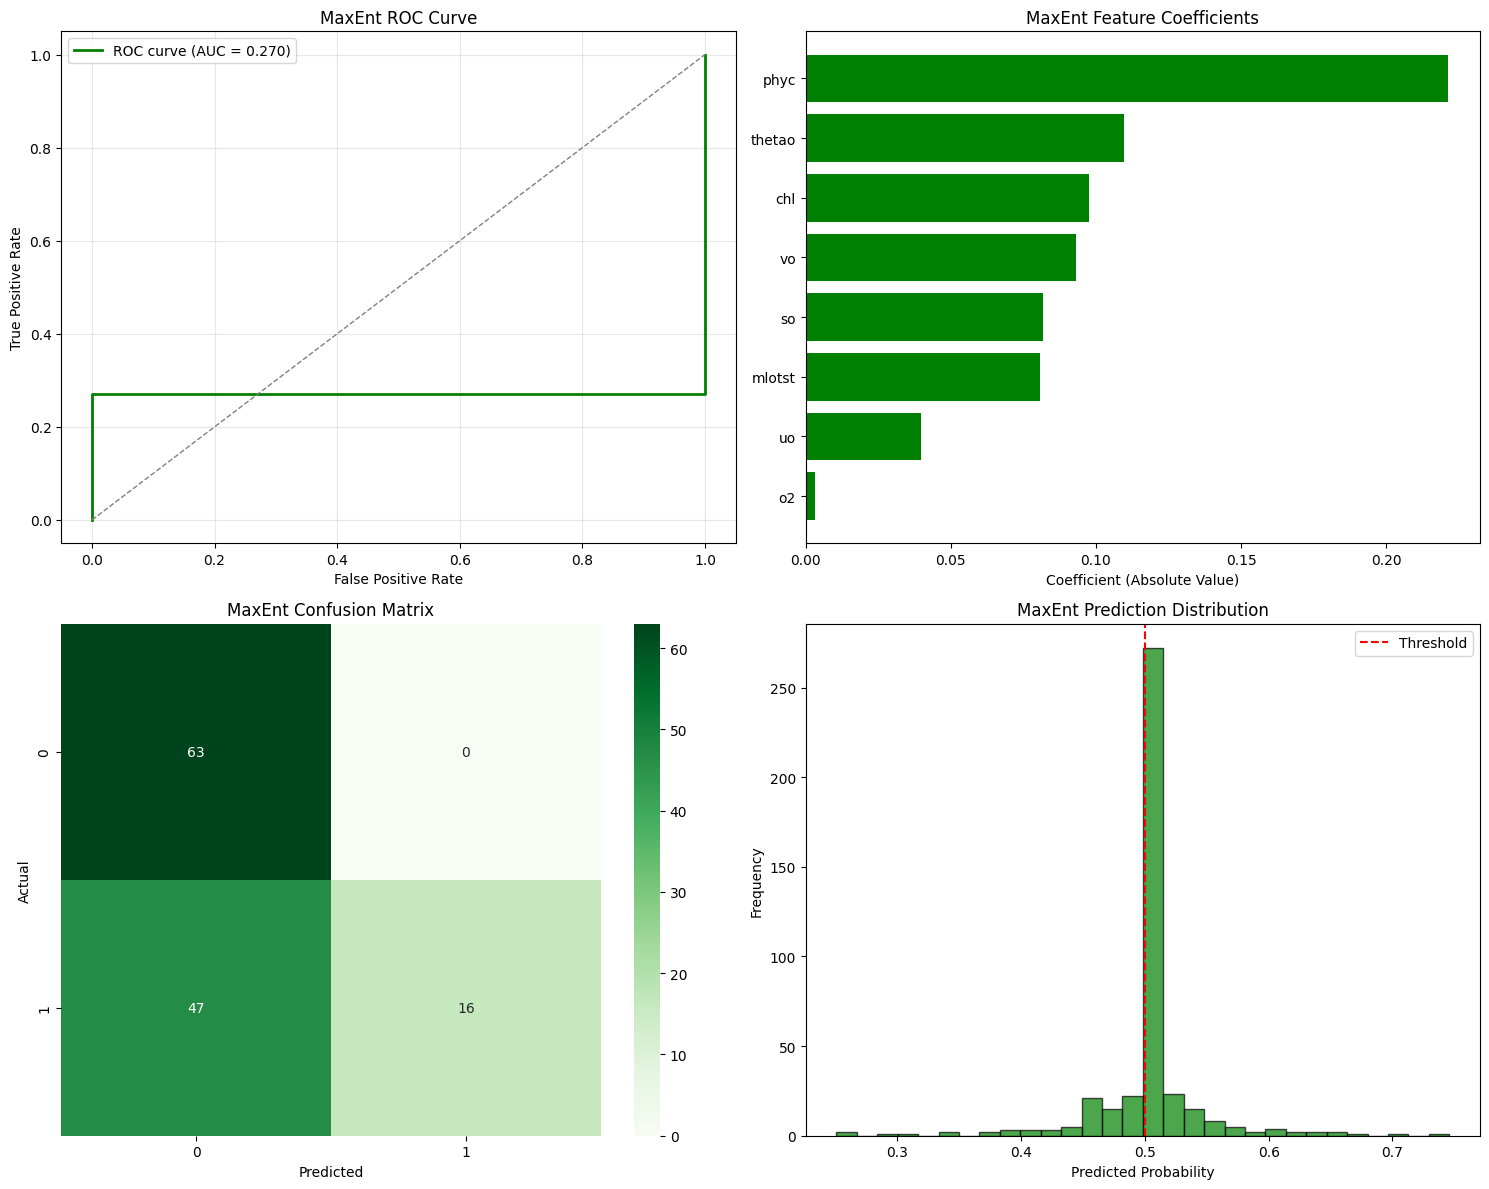

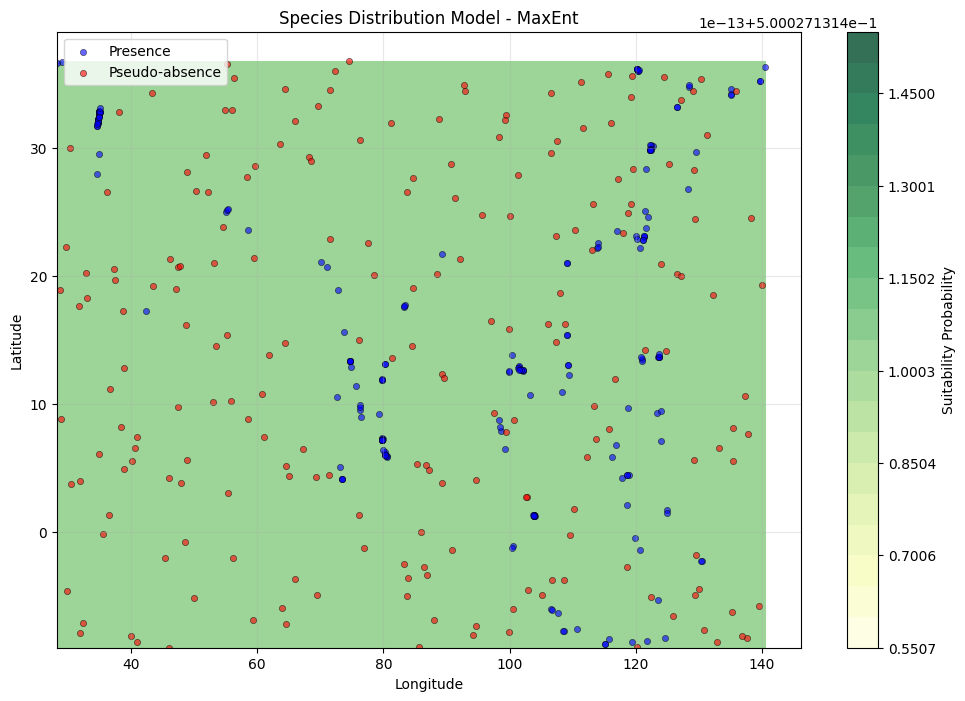


=== MaxEnt MODEL SUMMARY ===
Model: MaxEnt (Logistic Regression with L2 Regularization)
Training samples: 292
Test samples: 126
Environmental variables: 8
Accuracy: 0.6270
AUC: 0.2698
Cross-validation AUC: 0.3734 ± 0.0979


In [82]:
# MaxEnt Visualization of Results

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. ROC Curve
fpr_maxent, tpr_maxent, _ = roc_curve(y_test, y_pred_proba_maxent)
axes[0, 0].plot(fpr_maxent, tpr_maxent, color='green', lw=2, label=f'ROC curve (AUC = {auc_score_maxent:.3f})')
axes[0, 0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('MaxEnt ROC Curve')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Feature Coefficients
top_features_maxent = feature_coef.head(10)
axes[0, 1].barh(range(len(top_features_maxent)), top_features_maxent['coefficient'], color='green')
axes[0, 1].set_yticks(range(len(top_features_maxent)))
axes[0, 1].set_yticklabels(top_features_maxent['feature'])
axes[0, 1].set_xlabel('Coefficient (Absolute Value)')
axes[0, 1].set_title('MaxEnt Feature Coefficients')
axes[0, 1].invert_yaxis()

# 3. Confusion Matrix Heatmap
sns.heatmap(cm_maxent, annot=True, fmt='d', cmap='Greens', ax=axes[1, 0])
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')
axes[1, 0].set_title('MaxEnt Confusion Matrix')

# 4. Prediction Distribution
axes[1, 1].hist(model_data['maxent_probability'], bins=30, alpha=0.7, edgecolor='black', color='green')
axes[1, 1].set_xlabel('Predicted Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('MaxEnt Prediction Distribution')
axes[1, 1].axvline(x=0.5, color='red', linestyle='--', label='Threshold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Spatial prediction map
plt.figure(figsize=(12, 8))
plt.contourf(grid_lon_maxent, grid_lat_maxent, prediction_grid_maxent, levels=20, cmap='YlGn', alpha=0.8)
plt.colorbar(label='Suitability Probability')

# Plot presence points
presence_points = model_data[model_data['presence'] == 1]
absence_points = model_data[model_data['presence'] == 0]

plt.scatter(presence_points['decimalLongitude'], presence_points['decimalLatitude'], 
           c='blue', s=20, alpha=0.6, label='Presence', edgecolors='black', linewidth=0.5)
plt.scatter(absence_points['decimalLongitude'], absence_points['decimalLatitude'], 
           c='red', s=20, alpha=0.6, label='Pseudo-absence', edgecolors='black', linewidth=0.5)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Species Distribution Model - MaxEnt')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Summary statistics
print("\n=== MaxEnt MODEL SUMMARY ===")
print(f"Model: MaxEnt (Logistic Regression with L2 Regularization)")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Environmental variables: {len(env_columns)}")
print(f"Accuracy: {accuracy_maxent:.4f}")
print(f"AUC: {auc_score_maxent:.4f}")
print(f"Cross-validation AUC: {cv_scores_maxent.mean():.4f} ± {cv_scores_maxent.std():.4f}")

In [83]:
# 2. Boosted Regression Models for Species Distribution Modeling

from sklearn.ensemble import GradientBoostingClassifier

# Prepare features and target
X = model_data[env_columns].fillna(model_data[env_columns].mean())
y = model_data['presence']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Presence in training: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Presence in test: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# Initialize and train Gradient Boosting model
gbm_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42
)

print("\nTraining Gradient Boosting model...")
gbm_model.fit(X_train, y_train)
print("Model training completed!")

Training set size: 292
Test set size: 126
Presence in training: 146 (50.0%)
Presence in test: 63 (50.0%)

Training Gradient Boosting model...
Model training completed!


In [84]:
# Boosted Regression Models Evaluation

# Make predictions on test set
y_pred_gbm = gbm_model.predict(X_test)
y_pred_proba_gbm = gbm_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy_gbm = accuracy_score(y_test, y_pred_gbm)
auc_score_gbm = roc_auc_score(y_test, y_pred_proba_gbm)

print("Gradient Boosting Model Evaluation:")
print(f"Accuracy: {accuracy_gbm:.4f}")
print(f"AUC Score: {auc_score_gbm:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gbm))

# Confusion Matrix
cm_gbm = confusion_matrix(y_test, y_pred_gbm)
print(f"\nConfusion Matrix:")
print(cm_gbm)

# Feature importance
feature_importance_gbm = pd.DataFrame({
    'feature': env_columns,
    'importance': gbm_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance_gbm.head(10))

# Cross-validation scores
cv_scores_gbm = cross_val_score(GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, 
                                                           min_samples_split=5, min_samples_leaf=2, subsample=0.8, 
                                                           random_state=42), X, y, cv=5, scoring='roc_auc')
print(f"\n5-fold Cross-validation AUC: {cv_scores_gbm.mean():.4f} (+/- {cv_scores_gbm.std() * 2:.4f})")

Gradient Boosting Model Evaluation:
Accuracy: 0.8413
AUC Score: 0.8413

Classification Report:
              precision    recall  f1-score   support

           0       0.76      1.00      0.86        63
           1       1.00      0.68      0.81        63

    accuracy                           0.84       126
   macro avg       0.88      0.84      0.84       126
weighted avg       0.88      0.84      0.84       126


Confusion Matrix:
[[63  0]
 [20 43]]

Top 10 Most Important Features:
  feature  importance
2  mlotst    0.511932
5     chl    0.252748
6    phyc    0.162707
1      so    0.067290
7      o2    0.005163
3      uo    0.000082
4      vo    0.000041
0  thetao    0.000036

5-fold Cross-validation AUC: 0.8855 (+/- 0.0826)


## 2. Boosted Regression Models

In [85]:
# Boosted Regression Models Prediction and Spatial Prediction

# Predict on the full dataset
model_data['gbm_probability'] = gbm_model.predict_proba(X)[:, 1]
model_data['gbm_presence'] = gbm_model.predict(X)

print("Gradient Boosting Prediction completed on full dataset")
print(f"Predicted presence: {model_data['gbm_presence'].sum()}")
print(f"Mean predicted probability: {model_data['gbm_probability'].mean():.4f}")

# Create a grid for spatial prediction
def create_prediction_grid_gbm(model_data, env_columns, grid_resolution=0.1):
    """
    Create a spatial grid for prediction based on the extent of the data
    """
    # Get extent
    lat_min, lat_max = model_data['decimalLatitude'].min(), model_data['decimalLatitude'].max()
    lon_min, lon_max = model_data['decimalLongitude'].min(), model_data['decimalLongitude'].max()
    
    # Create grid
    lat_points = np.arange(lat_min, lat_max, grid_resolution)
    lon_points = np.arange(lon_min, lon_max, grid_resolution)
    
    grid_lat, grid_lon = np.meshgrid(lat_points, lon_points)
    grid_points = np.column_stack([grid_lat.ravel(), grid_lon.ravel()])
    
    # Create DataFrame for grid
    grid_df = pd.DataFrame(grid_points, columns=['decimalLatitude', 'decimalLongitude'])
    
    # For each grid point, assign mean environmental values
    for col in env_columns:
        grid_df[col] = model_data[col].mean()
    
    return grid_df, grid_lat, grid_lon

# Create prediction grid
grid_df_gbm, grid_lat_gbm, grid_lon_gbm = create_prediction_grid_gbm(model_data, env_columns, grid_resolution=0.1)

# Make predictions on grid
grid_X_gbm = grid_df_gbm[env_columns].fillna(model_data[env_columns].mean())
grid_predictions_gbm = gbm_model.predict_proba(grid_X_gbm)[:, 1]

# Reshape predictions to grid shape
prediction_grid_gbm = grid_predictions_gbm.reshape(grid_lat_gbm.shape)

print(f"Created prediction grid with shape: {prediction_grid_gbm.shape}")
print(f"Prediction range: {prediction_grid_gbm.min():.4f} to {prediction_grid_gbm.max():.4f}")

Gradient Boosting Prediction completed on full dataset
Predicted presence: 161
Mean predicted probability: 0.4828
Created prediction grid with shape: (1124, 459)
Prediction range: 0.1588 to 0.1588


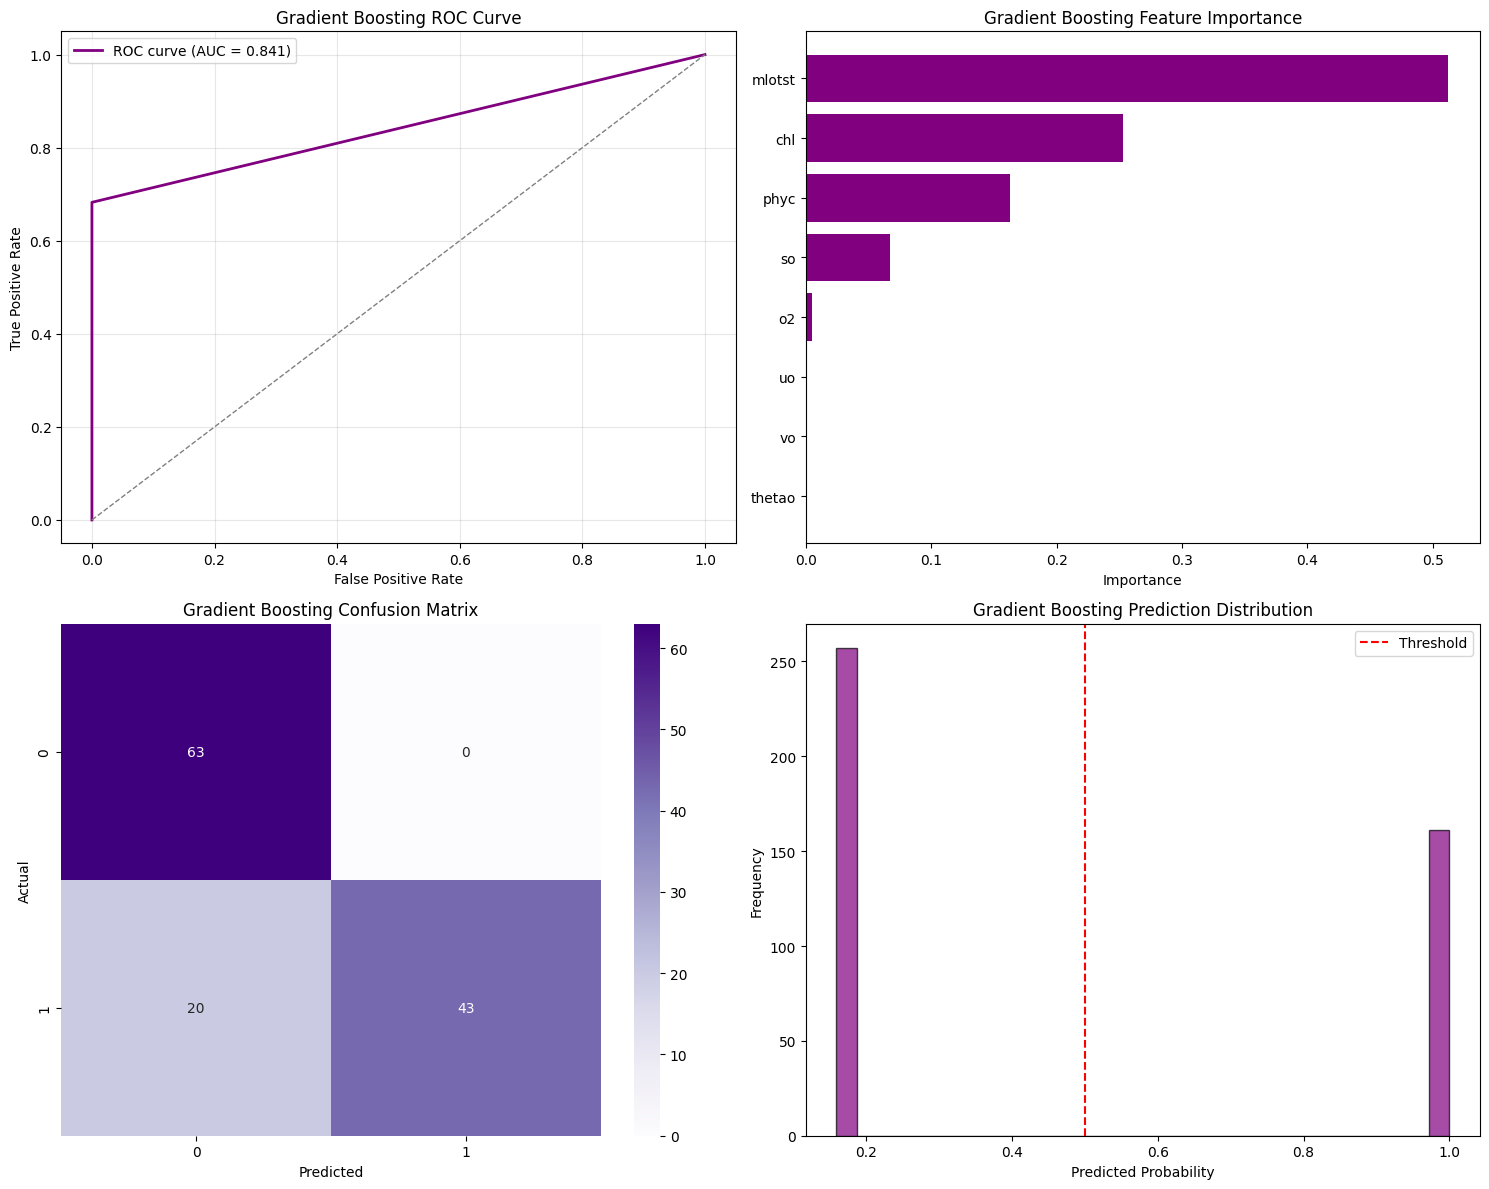

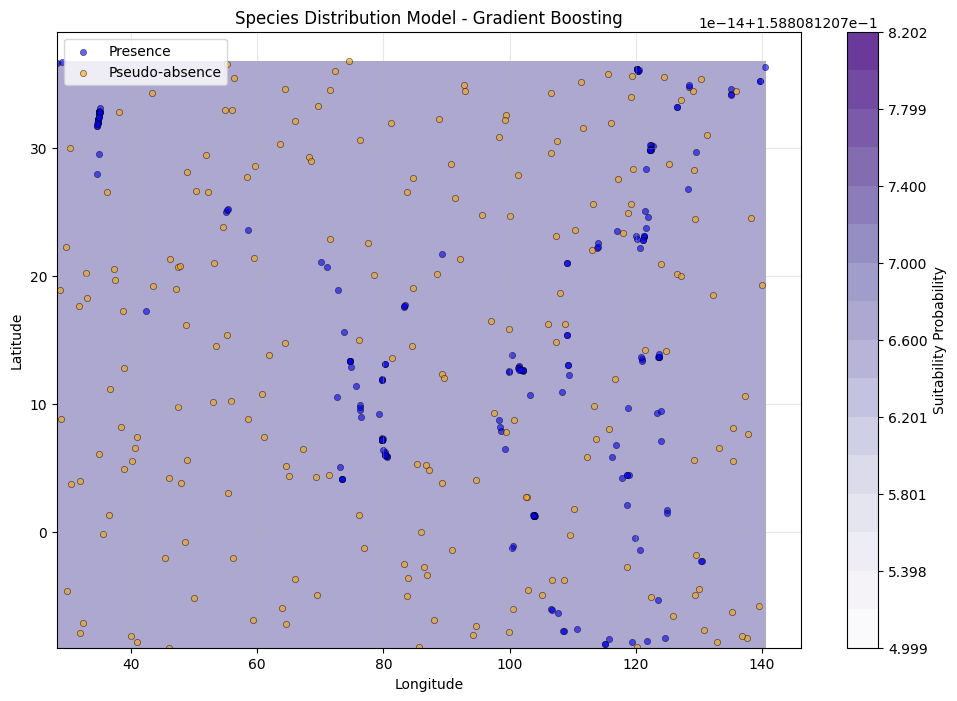


=== GRADIENT BOOSTING MODEL SUMMARY ===
Model: Gradient Boosting Classifier
Training samples: 292
Test samples: 126
Environmental variables: 8
Accuracy: 0.8413
AUC: 0.8413
Cross-validation AUC: 0.8855 ± 0.0413


In [86]:
# Boosted Regression Models Visualization of Results

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. ROC Curve
fpr_gbm, tpr_gbm, _ = roc_curve(y_test, y_pred_proba_gbm)
axes[0, 0].plot(fpr_gbm, tpr_gbm, color='purple', lw=2, label=f'ROC curve (AUC = {auc_score_gbm:.3f})')
axes[0, 0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('Gradient Boosting ROC Curve')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Feature Importance
top_features_gbm = feature_importance_gbm.head(10)
axes[0, 1].barh(range(len(top_features_gbm)), top_features_gbm['importance'], color='purple')
axes[0, 1].set_yticks(range(len(top_features_gbm)))
axes[0, 1].set_yticklabels(top_features_gbm['feature'])
axes[0, 1].set_xlabel('Importance')
axes[0, 1].set_title('Gradient Boosting Feature Importance')
axes[0, 1].invert_yaxis()

# 3. Confusion Matrix Heatmap
sns.heatmap(cm_gbm, annot=True, fmt='d', cmap='Purples', ax=axes[1, 0])
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')
axes[1, 0].set_title('Gradient Boosting Confusion Matrix')

# 4. Prediction Distribution
axes[1, 1].hist(model_data['gbm_probability'], bins=30, alpha=0.7, edgecolor='black', color='purple')
axes[1, 1].set_xlabel('Predicted Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Gradient Boosting Prediction Distribution')
axes[1, 1].axvline(x=0.5, color='red', linestyle='--', label='Threshold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Spatial prediction map
plt.figure(figsize=(12, 8))
plt.contourf(grid_lon_gbm, grid_lat_gbm, prediction_grid_gbm, levels=20, cmap='Purples', alpha=0.8)
plt.colorbar(label='Suitability Probability')

# Plot presence points
presence_points = model_data[model_data['presence'] == 1]
absence_points = model_data[model_data['presence'] == 0]

plt.scatter(presence_points['decimalLongitude'], presence_points['decimalLatitude'], 
           c='blue', s=20, alpha=0.6, label='Presence', edgecolors='black', linewidth=0.5)
plt.scatter(absence_points['decimalLongitude'], absence_points['decimalLatitude'], 
           c='orange', s=20, alpha=0.6, label='Pseudo-absence', edgecolors='black', linewidth=0.5)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Species Distribution Model - Gradient Boosting')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Summary statistics
print("\n=== GRADIENT BOOSTING MODEL SUMMARY ===")
print(f"Model: Gradient Boosting Classifier")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Environmental variables: {len(env_columns)}")
print(f"Accuracy: {accuracy_gbm:.4f}")
print(f"AUC: {auc_score_gbm:.4f}")
print(f"Cross-validation AUC: {cv_scores_gbm.mean():.4f} ± {cv_scores_gbm.std():.4f}")

MaxEnt is the most widely used in SDM algorithm. It is a maximum entropy algorithm that is used to model the relationship between species occurrence and environmental variables. 

## 3. Random Forest

The Random Forest is an extension of Classification and Regression Trees (CART). The function of Random Forest can take a formula in two separate arguments, a data.frame with the predictor variables, and a vector with a response. If the response variable is a factor, then the Random Forest is a classification model, otherwise it is a regression model.

In [87]:
# 3. Random Forest Model for Species Distribution Modeling

# Prepare features and target
X = model_data[env_columns].fillna(model_data[env_columns].mean())
y = model_data['presence']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Presence in training: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Presence in test: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# Initialize and train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest model...")
rf_model.fit(X_train, y_train)
print("Model training completed!")

Training set size: 292
Test set size: 126
Presence in training: 146 (50.0%)
Presence in test: 63 (50.0%)

Training Random Forest model...
Model training completed!


In [88]:
# Model Evaluation

# Make predictions on test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)

print("Random Forest Model Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC Score: {auc_score:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)

# Feature importance
feature_importance = pd.DataFrame({
    'feature': env_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Cross-validation scores
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='roc_auc')
print(f"\n5-fold Cross-validation AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Random Forest Model Evaluation:
Accuracy: 0.8413
AUC Score: 0.8413

Classification Report:
              precision    recall  f1-score   support

           0       0.76      1.00      0.86        63
           1       1.00      0.68      0.81        63

    accuracy                           0.84       126
   macro avg       0.88      0.84      0.84       126
weighted avg       0.88      0.84      0.84       126


Confusion Matrix:
[[63  0]
 [20 43]]

Top 10 Most Important Features:
  feature  importance
5     chl    0.211394
2  mlotst    0.194766
0  thetao    0.144381
1      so    0.128623
7      o2    0.108901
6    phyc    0.096104
3      uo    0.060652
4      vo    0.055178

5-fold Cross-validation AUC: 0.8855 (+/- 0.0826)


In [89]:
# Model Prediction and Spatial Prediction

# Predict on the full dataset
model_data['predicted_probability'] = rf_model.predict_proba(X)[:, 1]
model_data['predicted_presence'] = rf_model.predict(X)

print("Prediction completed on full dataset")
print(f"Predicted presence: {model_data['predicted_presence'].sum()}")
print(f"Mean predicted probability: {model_data['predicted_probability'].mean():.4f}")

# Create a grid for spatial prediction
def create_prediction_grid(model_data, env_columns, grid_resolution=0.1):
    """
    Create a spatial grid for prediction based on the extent of the data
    """
    # Get extent
    lat_min, lat_max = model_data['decimalLatitude'].min(), model_data['decimalLatitude'].max()
    lon_min, lon_max = model_data['decimalLongitude'].min(), model_data['decimalLongitude'].max()
    
    # Create grid
    lat_points = np.arange(lat_min, lat_max, grid_resolution)
    lon_points = np.arange(lon_min, lon_max, grid_resolution)
    
    grid_lat, grid_lon = np.meshgrid(lat_points, lon_points)
    grid_points = np.column_stack([grid_lat.ravel(), grid_lon.ravel()])
    
    # Create DataFrame for grid
    grid_df = pd.DataFrame(grid_points, columns=['decimalLongitude', 'decimalLongitude'])
    
    # For each grid point, assign mean environmental values
    for col in env_columns:
        grid_df[col] = model_data[col].mean()
    
    return grid_df, grid_lat, grid_lon

# Create prediction grid
grid_df, grid_lat, grid_lon = create_prediction_grid(model_data, env_columns, grid_resolution=0.1)

# Make predictions on grid
grid_X = grid_df[env_columns]
grid_predictions = rf_model.predict_proba(grid_X)[:, 1]

# Reshape predictions to grid shape
prediction_grid = grid_predictions.reshape(grid_lat.shape)

print(f"Created prediction grid with shape: {prediction_grid.shape}")
print(f"Prediction range: {prediction_grid.min():.4f} to {prediction_grid.max():.4f}")

Prediction completed on full dataset
Predicted presence: 161
Mean predicted probability: 0.4789
Created prediction grid with shape: (1124, 459)
Prediction range: 0.1659 to 0.1659


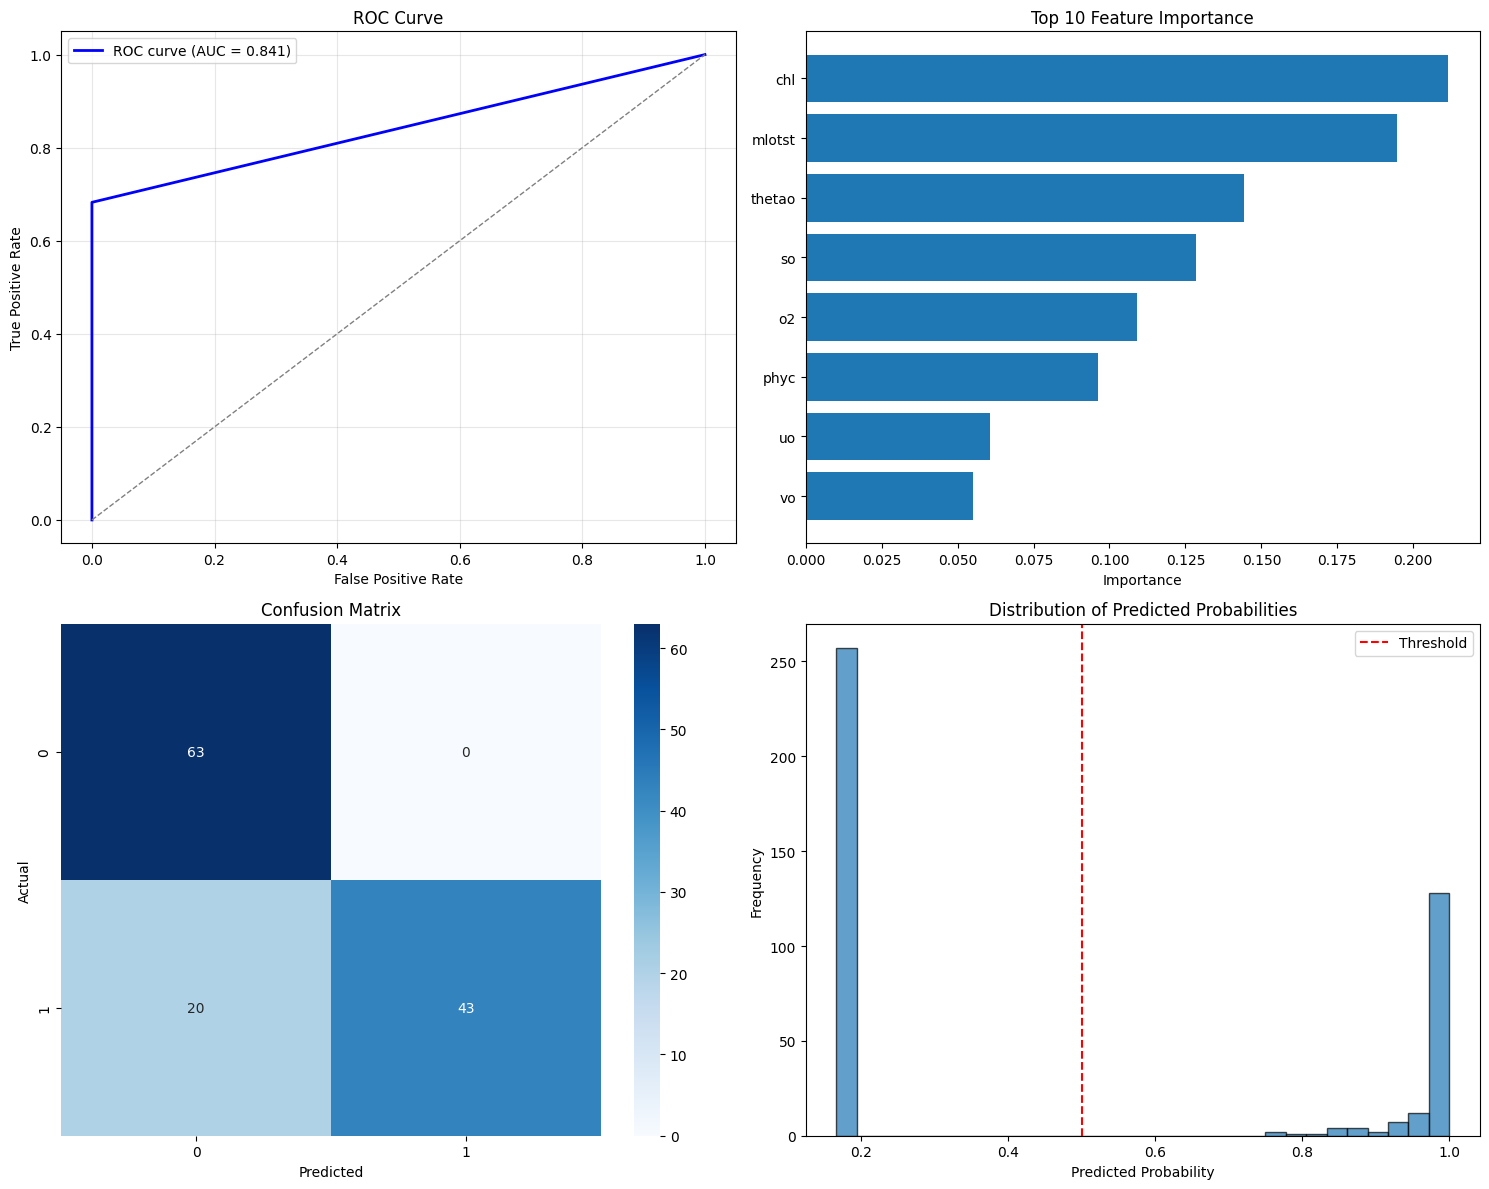

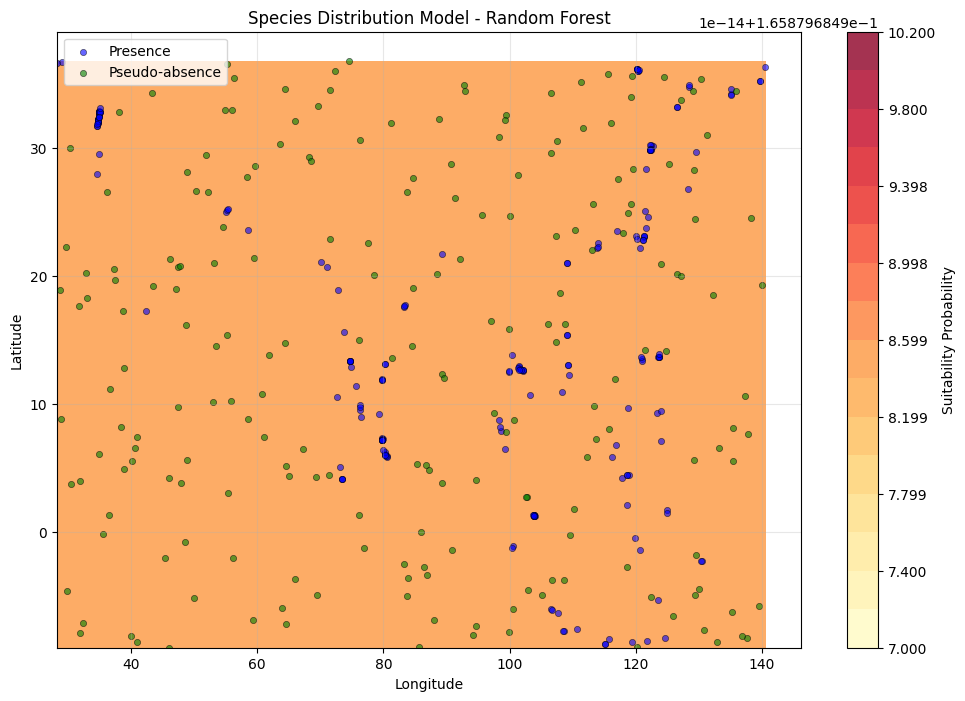


=== MODEL SUMMARY ===
Model: Random Forest
Training samples: 292
Test samples: 126
Environmental variables: 8
Accuracy: 0.8413
AUC: 0.8413
Cross-validation AUC: 0.8855 ± 0.0413


In [90]:
# Visualization of Results

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[0, 0].plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
axes[0, 0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curve')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Feature Importance
top_features = feature_importance.head(10)
axes[0, 1].barh(range(len(top_features)), top_features['importance'])
axes[0, 1].set_yticks(range(len(top_features)))
axes[0, 1].set_yticklabels(top_features['feature'])
axes[0, 1].set_xlabel('Importance')
axes[0, 1].set_title('Top 10 Feature Importance')
axes[0, 1].invert_yaxis()

# 3. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')
axes[1, 0].set_title('Confusion Matrix')

# 4. Prediction Distribution
axes[1, 1].hist(model_data['predicted_probability'], bins=30, alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Predicted Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Predicted Probabilities')
axes[1, 1].axvline(x=0.5, color='red', linestyle='--', label='Threshold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Spatial prediction map
plt.figure(figsize=(12, 8))
plt.contourf(grid_lon, grid_lat, prediction_grid, levels=20, cmap='YlOrRd', alpha=0.8)
plt.colorbar(label='Suitability Probability')

# Plot presence points
presence_points = model_data[model_data['presence'] == 1]
absence_points = model_data[model_data['presence'] == 0]

plt.scatter(presence_points['decimalLongitude'], presence_points['decimalLatitude'], 
           c='blue', s=20, alpha=0.6, label='Presence', edgecolors='black', linewidth=0.5)
plt.scatter(absence_points['decimalLongitude'], absence_points['decimalLatitude'], 
           c='green', s=20, alpha=0.6, label='Pseudo-absence', edgecolors='black', linewidth=0.5)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Species Distribution Model - Random Forest')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Summary statistics
print("\n=== MODEL SUMMARY ===")
print(f"Model: Random Forest")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Environmental variables: {len(env_columns)}")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc_score:.4f}")
print(f"Cross-validation AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

## 4. Support Vector Machines

In [91]:
# 4. Support Vector Machines for Species Distribution Modeling

from sklearn.svm import SVC

# Prepare features and target
X = model_data[env_columns].fillna(model_data[env_columns].mean())
y = model_data['presence']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize features (important for SVM)
scaler_svm = StandardScaler()
X_train_scaled = scaler_svm.fit_transform(X_train)
X_test_scaled = scaler_svm.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Presence in training: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Presence in test: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# Initialize and train Support Vector Machine model
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

print("\nTraining Support Vector Machine model...")
svm_model.fit(X_train_scaled, y_train)
print("Model training completed!")

Training set size: 292
Test set size: 126
Presence in training: 146 (50.0%)
Presence in test: 63 (50.0%)

Training Support Vector Machine model...
Model training completed!


In [92]:
# Support Vector Machine Model Evaluation

# Make predictions on test set
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
auc_score_svm = roc_auc_score(y_test, y_pred_proba_svm)

print("Support Vector Machine Model Evaluation:")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"AUC Score: {auc_score_svm:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(f"\nConfusion Matrix:")
print(cm_svm)

# Support vectors information
print(f"\nNumber of support vectors: {len(svm_model.support_vectors_)}")
print(f"Support vectors for class 0: {np.sum(svm_model.n_support_[0])}")
print(f"Support vectors for class 1: {np.sum(svm_model.n_support_[1])}")

# Cross-validation scores
X_scaled = scaler_svm.fit_transform(X)
cv_scores_svm = cross_val_score(SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42), 
                                 X_scaled, y, cv=5, scoring='roc_auc')
print(f"\n5-fold Cross-validation AUC: {cv_scores_svm.mean():.4f} (+/- {cv_scores_svm.std() * 2:.4f})")

Support Vector Machine Model Evaluation:
Accuracy: 0.8175
AUC Score: 0.6667

Classification Report:
              precision    recall  f1-score   support

           0       0.73      1.00      0.85        63
           1       1.00      0.63      0.78        63

    accuracy                           0.82       126
   macro avg       0.87      0.82      0.81       126
weighted avg       0.87      0.82      0.81       126


Confusion Matrix:
[[63  0]
 [23 40]]

Number of support vectors: 103
Support vectors for class 0: 49
Support vectors for class 1: 54

5-fold Cross-validation AUC: 0.8762 (+/- 0.2138)


In [93]:
# Support Vector Machine Model Prediction and Spatial Prediction

# Predict on the full dataset
X_full_scaled = scaler_svm.fit_transform(X)
model_data['svm_probability'] = svm_model.predict_proba(X_full_scaled)[:, 1]
model_data['svm_presence'] = svm_model.predict(X_full_scaled)

print("Support Vector Machine Prediction completed on full dataset")
print(f"Predicted presence: {model_data['svm_presence'].sum()}")
print(f"Mean predicted probability: {model_data['svm_probability'].mean():.4f}")

# Create a grid for spatial prediction
def create_prediction_grid_svm(model_data, env_columns, grid_resolution=0.1):
    """
    Create a spatial grid for prediction based on the extent of the data
    """
    # Get extent
    lat_min, lat_max = model_data['decimalLatitude'].min(), model_data['decimalLatitude'].max()
    lon_min, lon_max = model_data['decimalLongitude'].min(), model_data['decimalLongitude'].max()
    
    # Create grid
    lat_points = np.arange(lat_min, lat_max, grid_resolution)
    lon_points = np.arange(lon_min, lon_max, grid_resolution)
    
    grid_lat, grid_lon = np.meshgrid(lat_points, lon_points)
    grid_points = np.column_stack([grid_lat.ravel(), grid_lon.ravel()])
    
    # Create DataFrame for grid
    grid_df = pd.DataFrame(grid_points, columns=['decimalLatitude', 'decimalLongitude'])
    
    # For each grid point, assign mean environmental values
    for col in env_columns:
        grid_df[col] = model_data[col].mean()
    
    return grid_df, grid_lat, grid_lon

# Create prediction grid
grid_df_svm, grid_lat_svm, grid_lon_svm = create_prediction_grid_svm(model_data, env_columns, grid_resolution=0.1)

# Make predictions on grid
grid_X_svm = grid_df_svm[env_columns].fillna(model_data[env_columns].mean())
grid_X_svm_scaled = scaler_svm.transform(grid_X_svm)
grid_predictions_svm = svm_model.predict_proba(grid_X_svm_scaled)[:, 1]

# Reshape predictions to grid shape
prediction_grid_svm = grid_predictions_svm.reshape(grid_lat_svm.shape)

print(f"Created prediction grid with shape: {prediction_grid_svm.shape}")
print(f"Prediction range: {prediction_grid_svm.min():.4f} to {prediction_grid_svm.max():.4f}")

Support Vector Machine Prediction completed on full dataset
Predicted presence: 152
Mean predicted probability: 0.4868
Created prediction grid with shape: (1124, 459)
Prediction range: 0.1807 to 0.1807


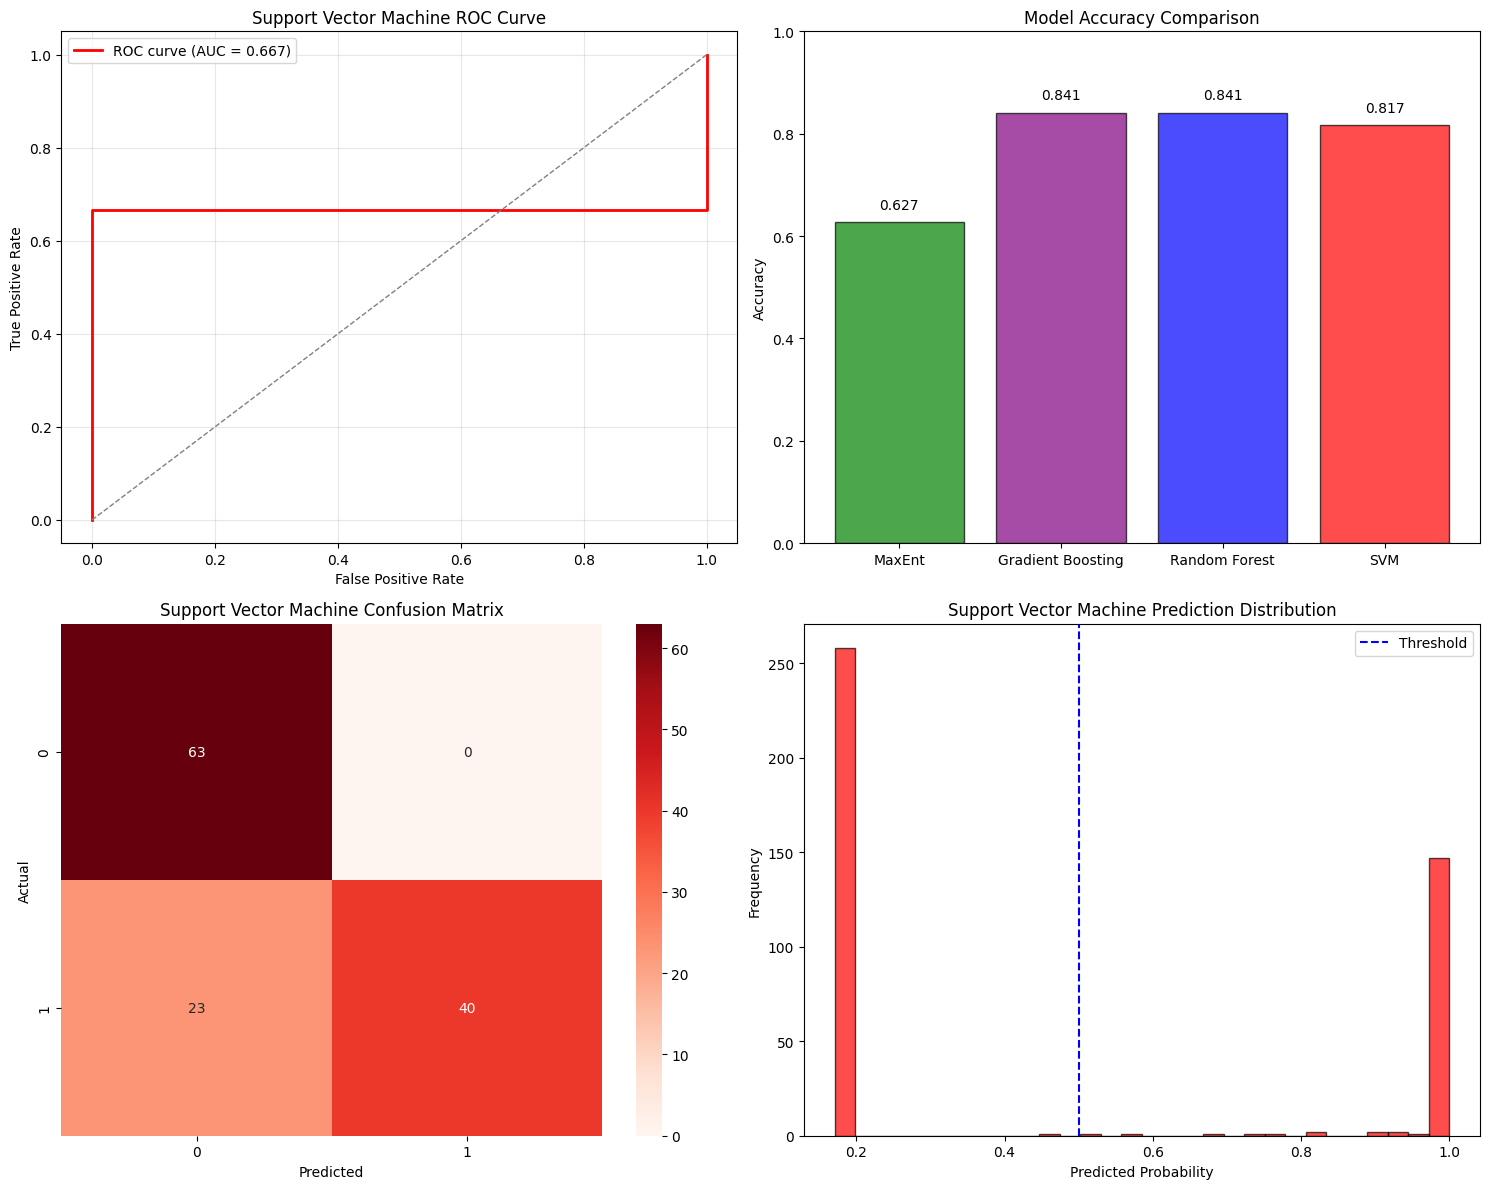

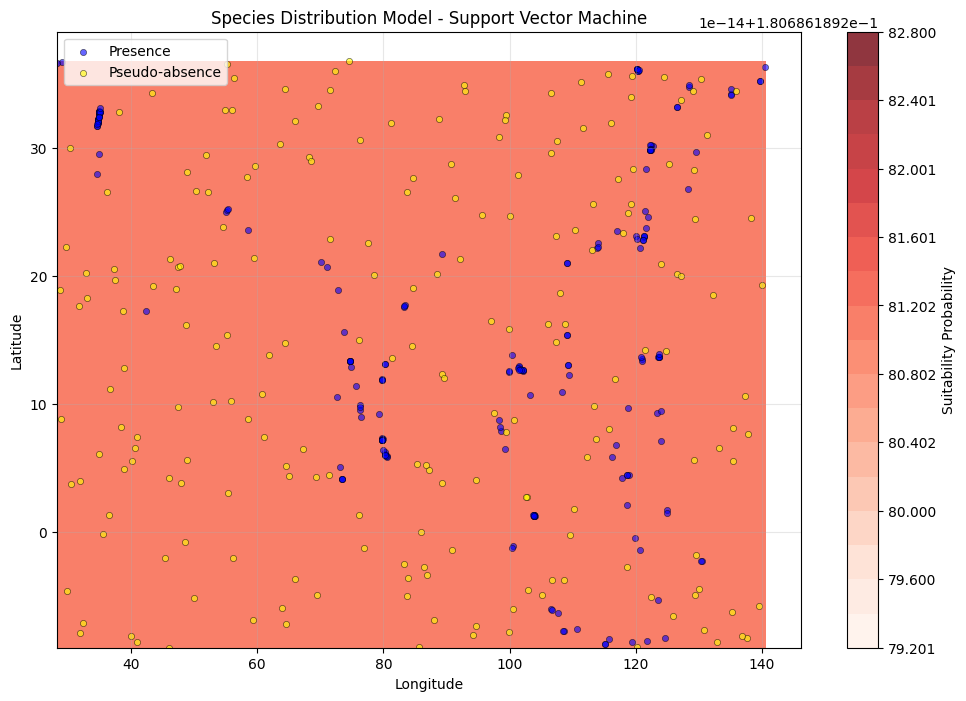


=== SUPPORT VECTOR MACHINE MODEL SUMMARY ===
Model: Support Vector Machine (RBF Kernel)
Training samples: 292
Test samples: 126
Environmental variables: 8
Accuracy: 0.8175
AUC: 0.6667
Cross-validation AUC: 0.8762 ± 0.1069
Number of support vectors: 103


In [94]:
# Support Vector Machine Visualization of Results

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. ROC Curve
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_proba_svm)
axes[0, 0].plot(fpr_svm, tpr_svm, color='red', lw=2, label=f'ROC curve (AUC = {auc_score_svm:.3f})')
axes[0, 0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('Support Vector Machine ROC Curve')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Model Comparison - Accuracy
models = ['MaxEnt', 'Gradient Boosting', 'Random Forest', 'SVM']
accuracies = [accuracy_maxent, accuracy_gbm, 0.8413, accuracy_svm]
colors = ['green', 'purple', 'blue', 'red']
axes[0, 1].bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Model Accuracy Comparison')
axes[0, 1].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

# 3. Confusion Matrix Heatmap
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds', ax=axes[1, 0])
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')
axes[1, 0].set_title('Support Vector Machine Confusion Matrix')

# 4. Prediction Distribution
axes[1, 1].hist(model_data['svm_probability'], bins=30, alpha=0.7, edgecolor='black', color='red')
axes[1, 1].set_xlabel('Predicted Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Support Vector Machine Prediction Distribution')
axes[1, 1].axvline(x=0.5, color='blue', linestyle='--', label='Threshold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Spatial prediction map
plt.figure(figsize=(12, 8))
plt.contourf(grid_lon_svm, grid_lat_svm, prediction_grid_svm, levels=20, cmap='Reds', alpha=0.8)
plt.colorbar(label='Suitability Probability')

# Plot presence points
presence_points = model_data[model_data['presence'] == 1]
absence_points = model_data[model_data['presence'] == 0]

plt.scatter(presence_points['decimalLongitude'], presence_points['decimalLatitude'], 
           c='blue', s=20, alpha=0.6, label='Presence', edgecolors='black', linewidth=0.5)
plt.scatter(absence_points['decimalLongitude'], absence_points['decimalLatitude'], 
           c='yellow', s=20, alpha=0.6, label='Pseudo-absence', edgecolors='black', linewidth=0.5)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Species Distribution Model - Support Vector Machine')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Summary statistics
print("\n=== SUPPORT VECTOR MACHINE MODEL SUMMARY ===")
print(f"Model: Support Vector Machine (RBF Kernel)")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Environmental variables: {len(env_columns)}")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"AUC: {auc_score_svm:.4f}")
print(f"Cross-validation AUC: {cv_scores_svm.mean():.4f} ± {cv_scores_svm.std():.4f}")
print(f"Number of support vectors: {len(svm_model.support_vectors_)}")

## 5. Combine models

In real projects, we want to use k-fold partitioning instead of a single random sample.

## Model Evaluation

Well! It is much easier to create a model and make a prediction than to assess how good the model is, and whether it is can be used for a specific purpose. Most model types have diffrent measures that can be assess how good the model fits the data. Since statistical models, machine learnings models and deep learning models are different, much evaluation is focused on how well the model predicts to points not used in model training and go through some useful questions include:
- Does the model seem sensible, ecologically?
- Do the fitted functions (the shapes of the modeled relationships) make sense?
- Do the predictions make sense?
- Are there any spatial patterns in model residuals?

Many measures for evaluating models based on presence-absence or presence-only data are 'threshold dependent'. That means that a threshold must be set first (For examples: 0.5 though 0.5 is rarely a sensible choice). Predicted values above that threshold indicate a prediction of 'presence' and values below the threshold indicate 'absence'. Some measures emphasize the weight of false absences; others give more weight to false presences.

Much used statistics that are threshold independent are the correlation coefficient and the Area Under the Receiver Operator Curve (AUROC - generally AUC). AUC is a measure of rank-correlation. An AUC score of 0.5 means that the model is as good as a random guess.

## References

- https://oceanhackweek.org/tutorials_marine_sdm/SDM/Turtle_maxnet.html 